In [1]:
import ftlelab as fl
# import ftlelab.configs as cfg
import ftlelab.models as fmods
import torch

import ftlelab.utils as utils
import ftlelab.data as datasets
import ftlelab.training as training

import jax

import numpy as np
import jax.numpy as jnp
from ftlelab.ftle.jax_transfer import pytorch_dense_to_jax_params
from ftlelab.ftle.jax_core import ftle_field_batched
jax.config.update("jax_enable_x64", True)

%load_ext autoreload
%autoreload 2

In [2]:
import ftlelab.ftle as ftle

In [3]:
X_circ, y_circ = datasets.make_circle_dataset(num_samples=15000,
                                              noise_std=0.1,
                                              seed=42)

data_circ = datasets.make_dataloaders(datasets.split_dataset(X_circ, y_circ), batch_size=12000)

In [18]:
net_1 = fmods.DenseNet([2, 10, 3, 10, 3, 10, 1], init_method="paper", output_activation="tanh")

In [20]:
config_c1 = training.TrainConfig(
    epochs=2000,
    batch_size=12000,
    optimizer='sgd',
    print_every=100,
    model_name="1",
    lr=1e-2
)

In [21]:
trainer = training.Trainer(net_1, config_c1)

Trainer for MODEL_1 initialized on device: cuda
Trainable parameters: 187 / 187


In [ ]:
results_1 = trainer.train(data_circ['train'], data_circ['val'])

In [4]:
net_1 = fmods.DenseNet([2, 10, 3, 10, 3, 10, 1], init_method="paper", output_activation="tanh")
net_1.load_state_dict(torch.load(f"checkpoints/BEST_MODEL1.pt")['model_state_dict']);

In [5]:
# 1. Load your trained PyTorch DenseNet
net_1.eval()

# 2. Convert to JAX params
params_jax = pytorch_dense_to_jax_params(net_1)

# 3. Build a grid of points in numpy (similar to grid.make_grid2d)
xs = np.linspace(-1.2, 1.2, 200, dtype=np.float32)
ys = np.linspace(-1.2, 1.2, 200, dtype=np.float32)
XX, YY = np.meshgrid(xs, ys, indexing="xy")
grid_np = np.stack([XX.reshape(-1), YY.reshape(-1)], axis=1)  # (N, 2)

X_jax = jnp.asarray(grid_np)


l_list = [10, 3, 10, 3, 10]
grids_jax = []
for i in range(1, 6):
    layer_spec = ("hidden_k", i)

    lam_np = ftle_field_batched(
        model_type="dense",
        params=params_jax,
        X_np=grid_np,
        layer_spec=("hidden_k", i),
        time_L=i,
        batch_size=2048,
        activation="tanh",
        output_activation="tanh",
        dtype="float32"
    )
    lam_np.reshape(YY.shape)  # reshape to (ny, nx) for plotting
    grids_jax.append(lam_np)
# 4. Compute FTLE field for last hidden layer (say depth L_hidden)




E0513 15:16:46.841015   24581 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0513 15:16:47.366137   21904 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


FTLE (JAX):   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [6]:
net_1.eval()
grid, _ = ftle.make_grid2d()

l_list = [10, 3, 10, 3, 10]
grids = []
for i in range(1, 6):
    gridd = ftle.compute_ftle_grid(net_1, ("hidden_k", i), time_L=l_list[i-1], grid=grid)
    grids.append(gridd)

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/40 [00:00<?, ?it/s]

In [15]:
_[0].shape

torch.Size([200, 200])

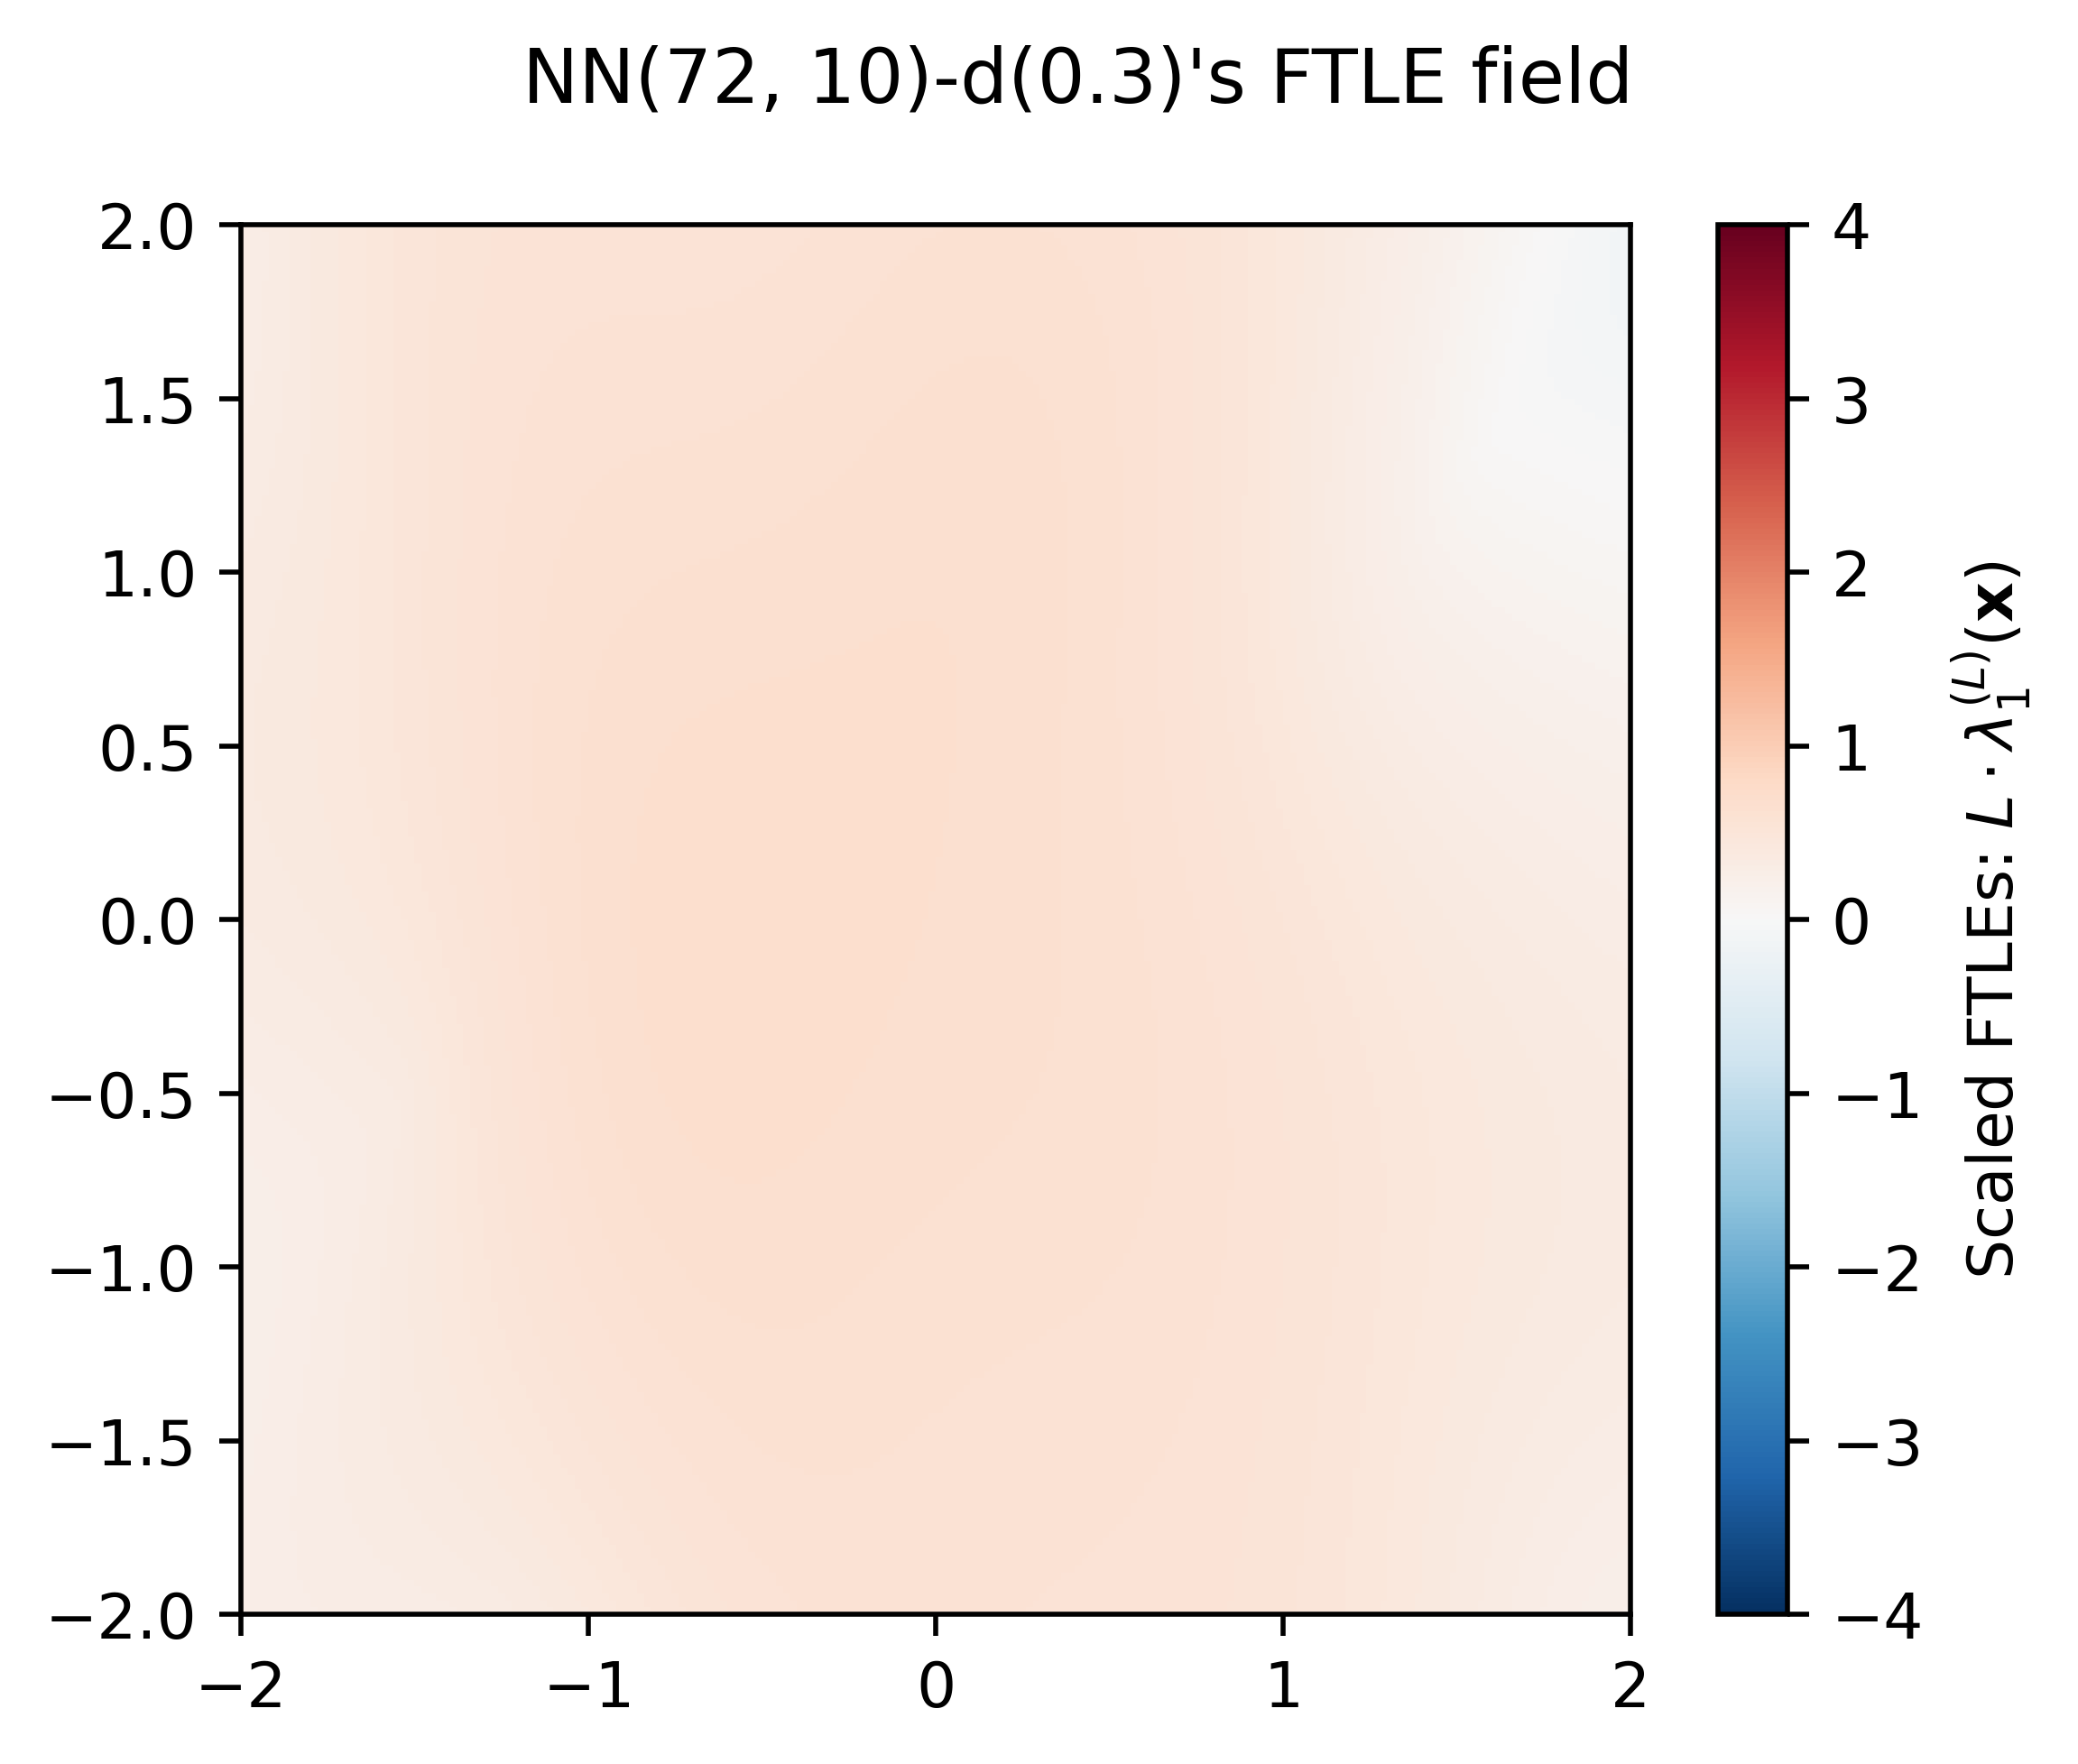

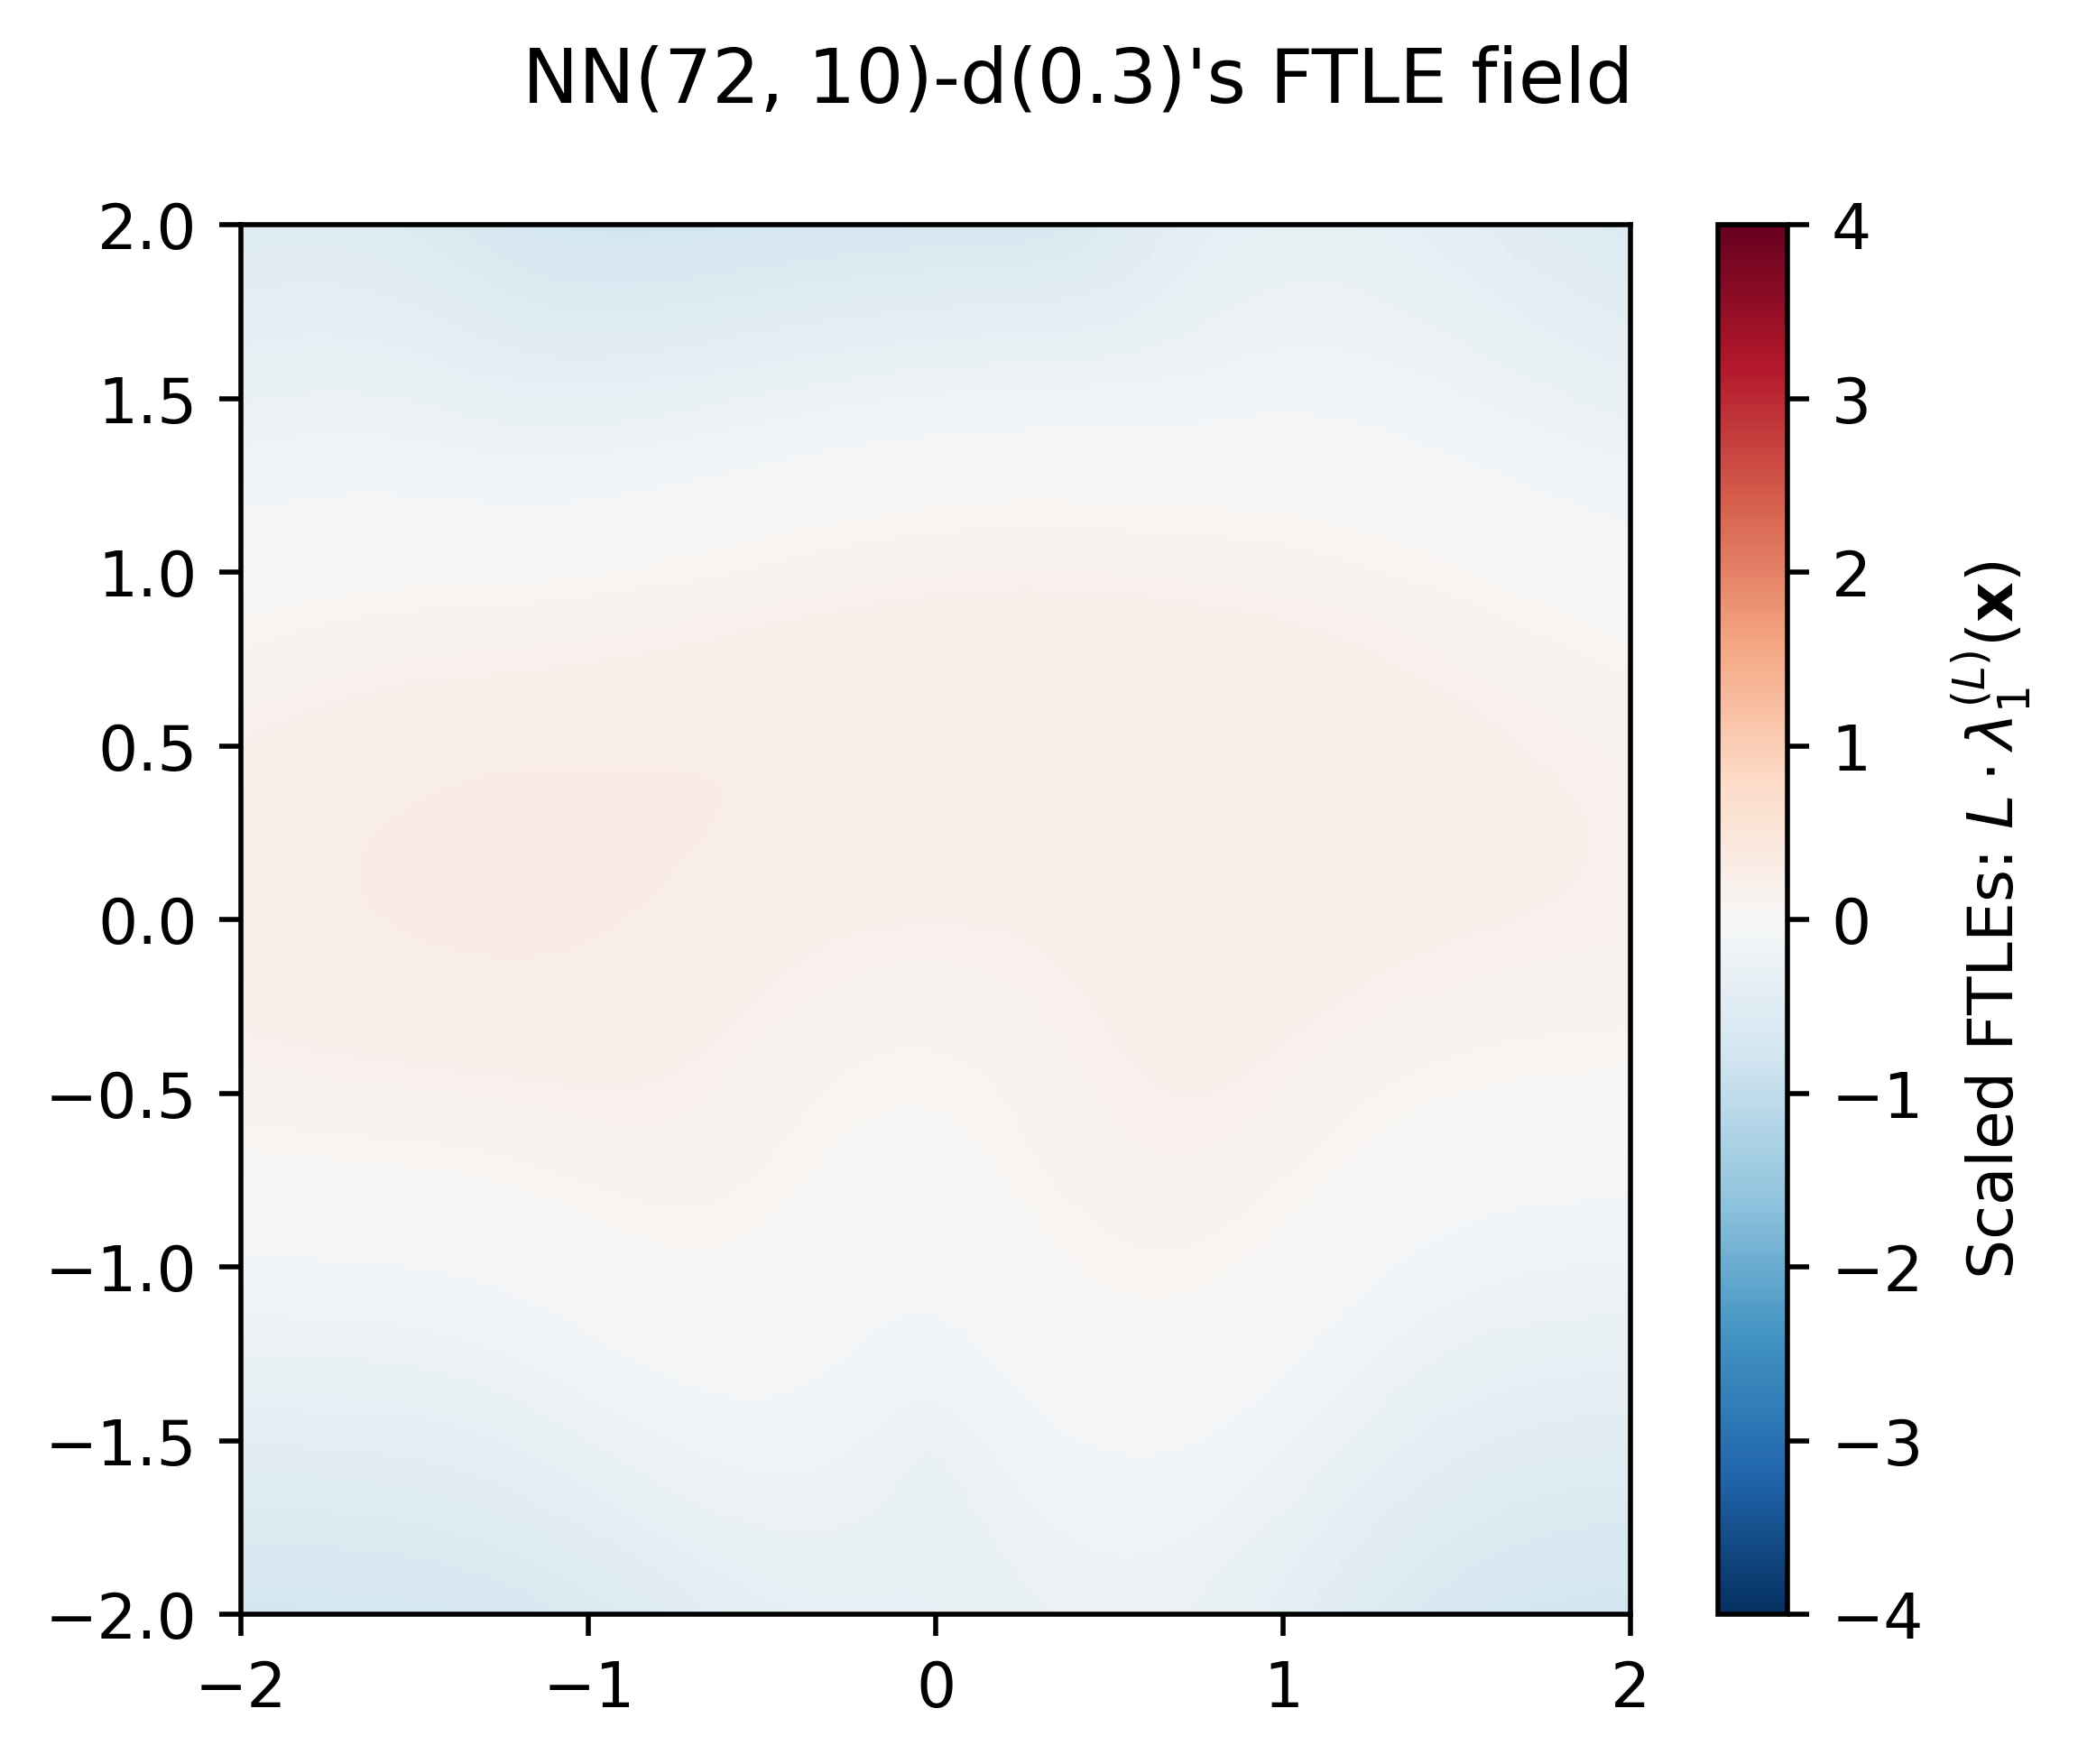

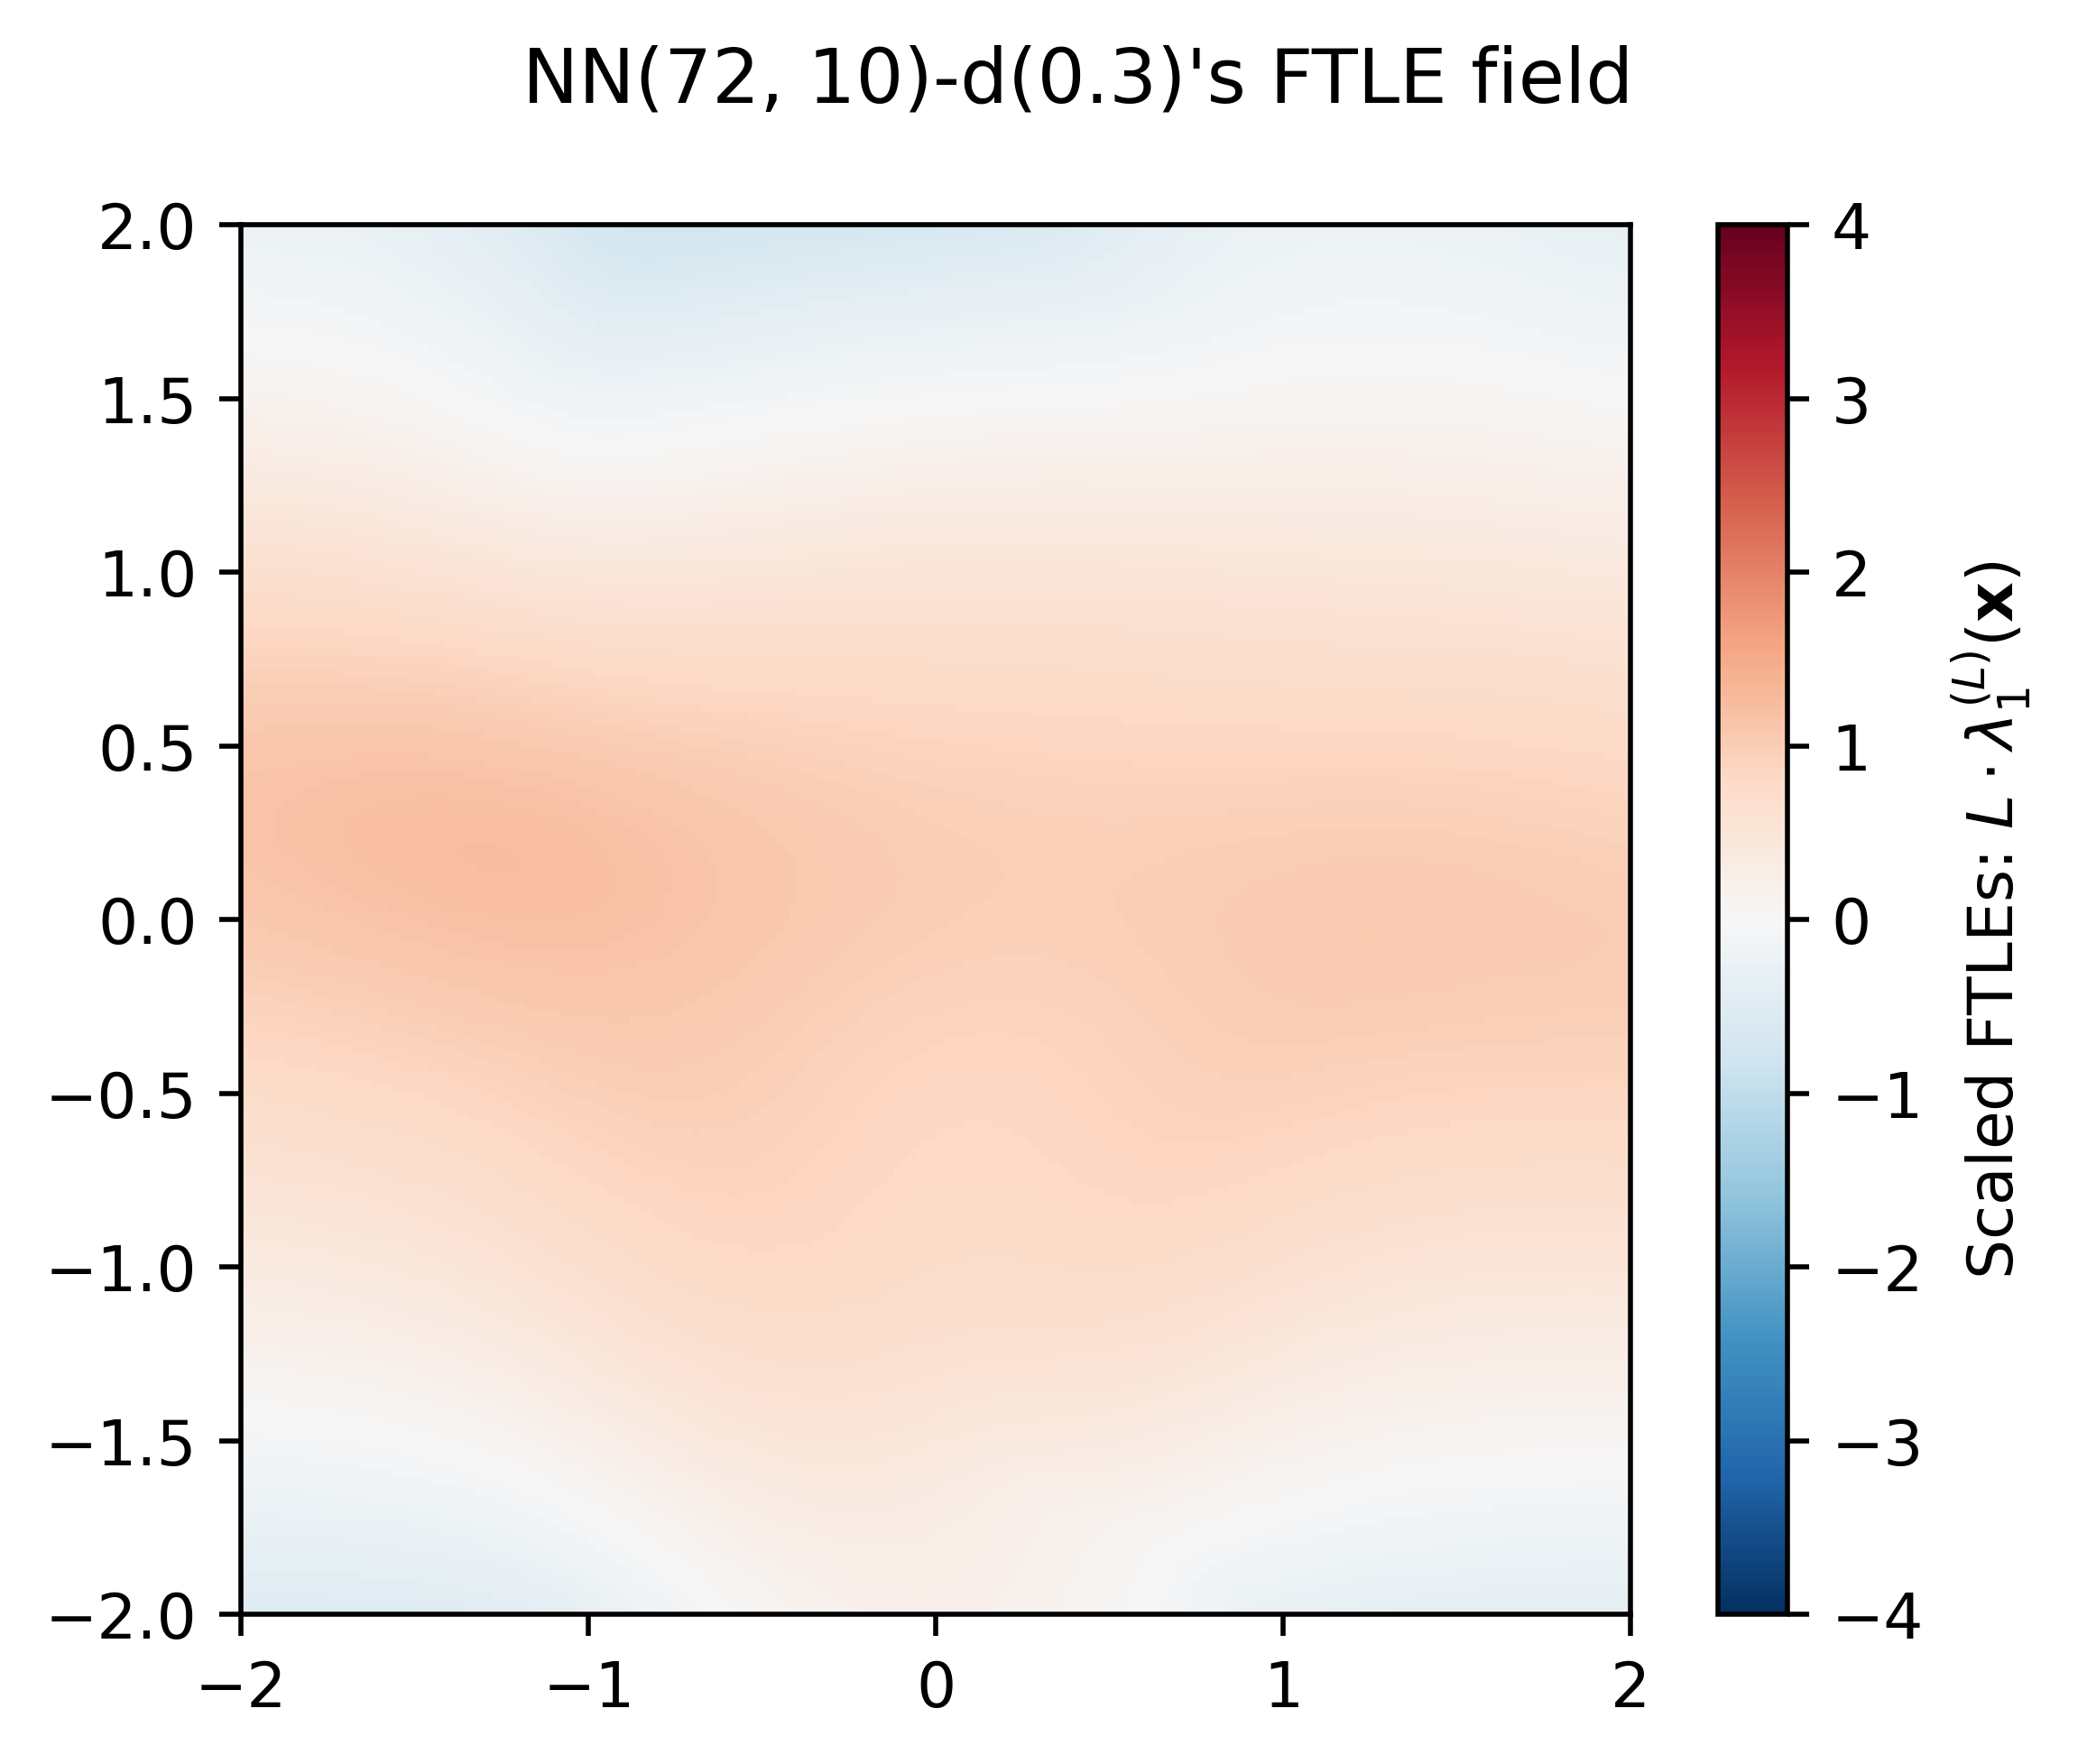

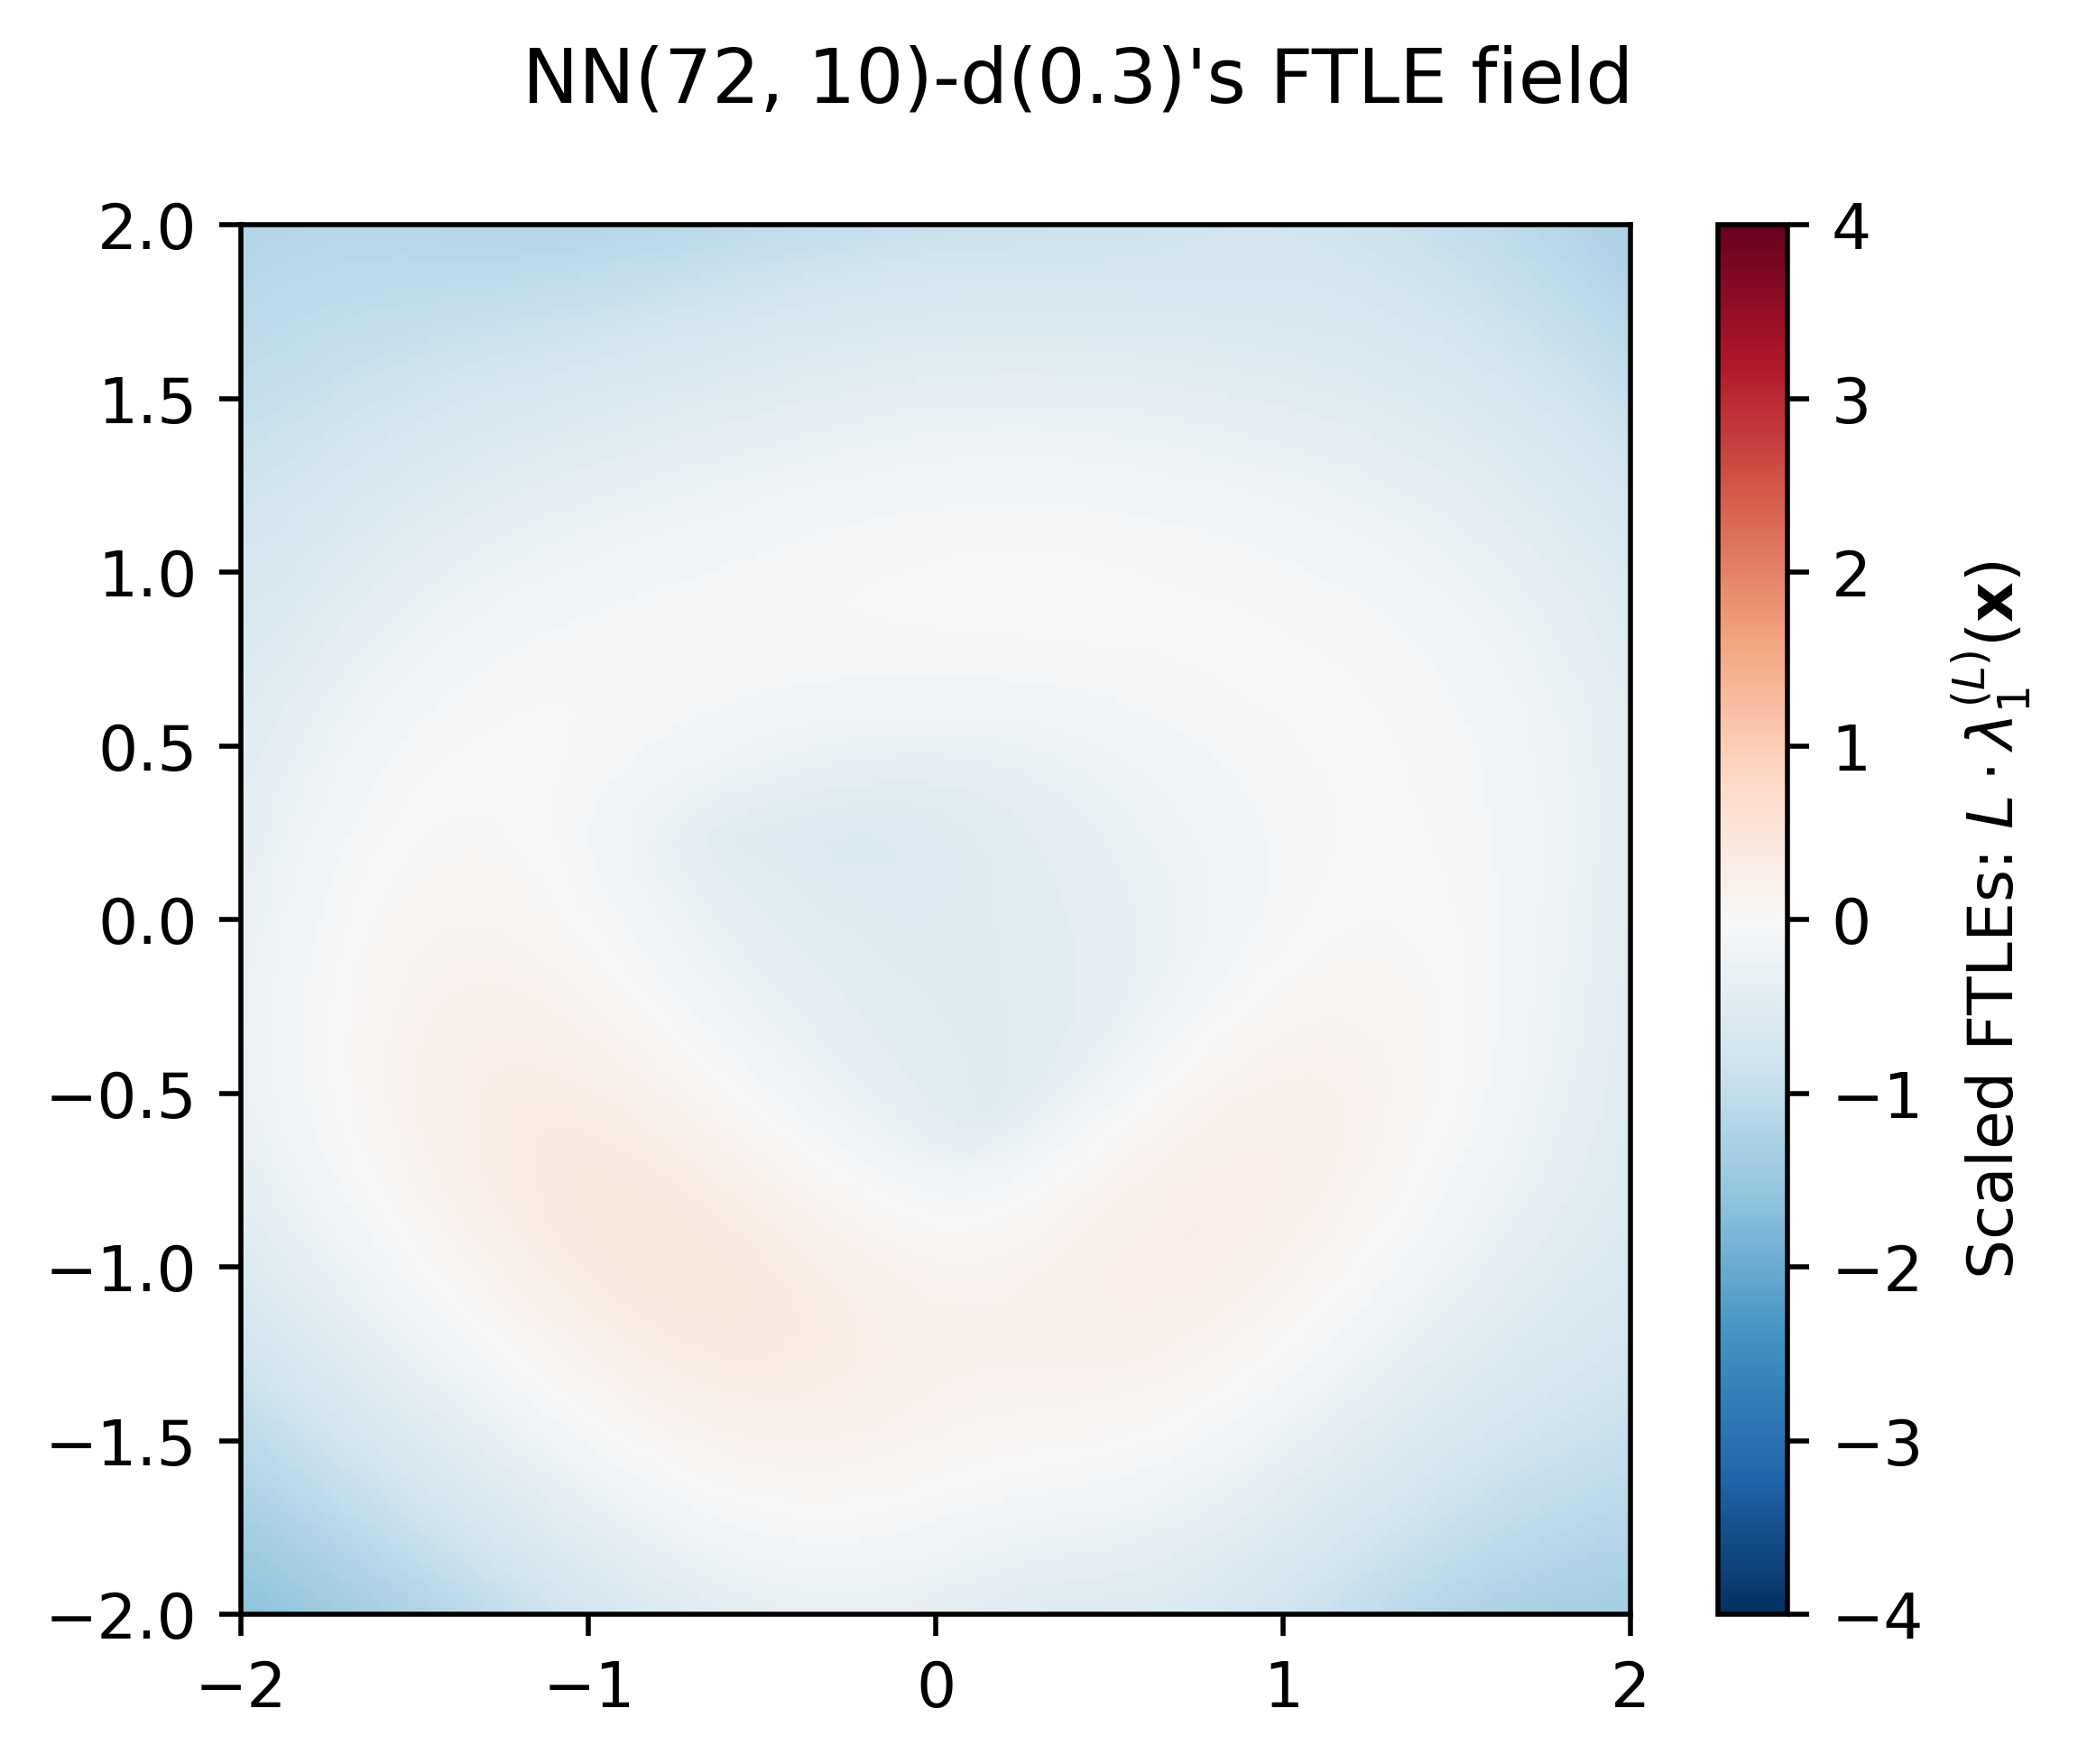

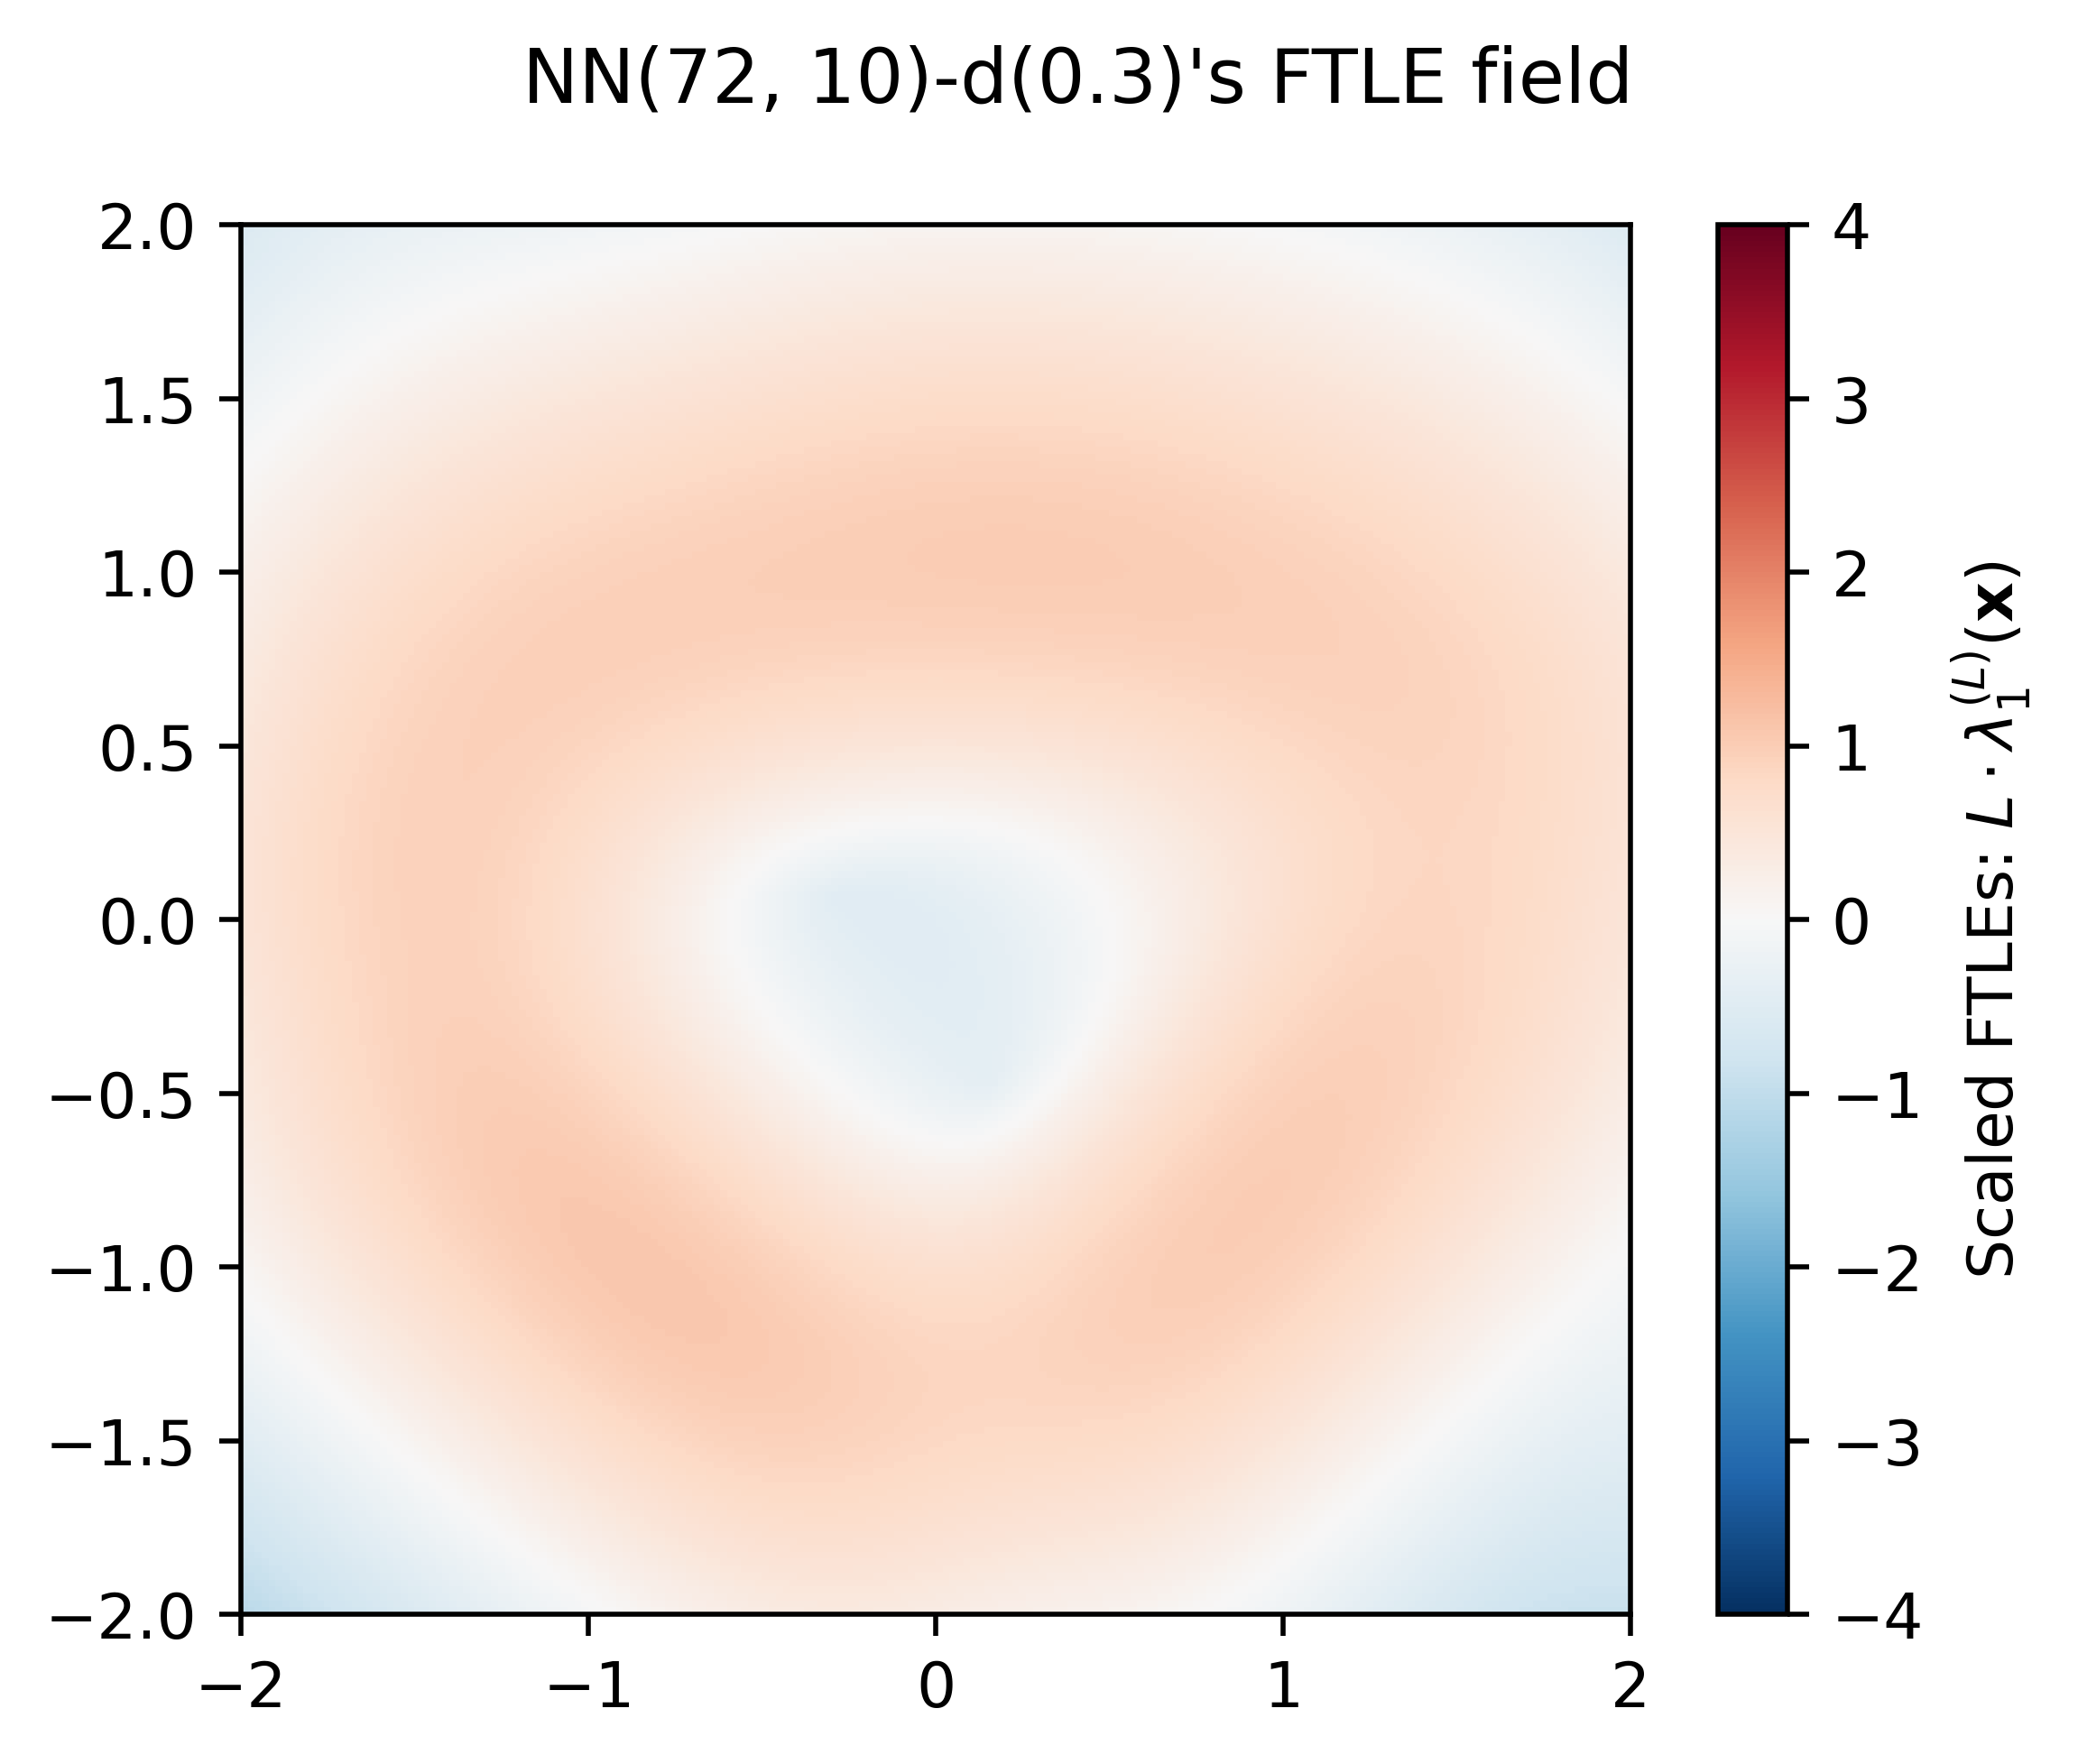

In [14]:
# 5) Plot (matplotlib)
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

for i in range(5):
    fig = plt.figure(figsize=(5,4), dpi=500)
    plt.imshow(l_list[i] * grids[i].reshape(200, 200),
            extent=(-2,2,-2,2), 
            origin="lower", 
            aspect="equal",
            cmap="RdBu_r",
            norm=TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4))
    plt.colorbar(label=r"Scaled FTLEs: $L\cdot\lambda_1^{(L)}(\mathbf{x})$", norm='log')
    fig.suptitle(r"NN(72, 10)-d(0.3)'s FTLE field")
    plt.show()

## Grid Experimenting

In [ ]:
mods.DenseNet([2, 10, 3, 10, 3, 10, 1], init_method="paper", output_activation="tanh")

In [ ]:
n_list = [3, 10, 50, 100, 250]
ell_list = [2, 4, 6, 8, 12]

networks_grid_params = {}
networks_grid = {}

for ell in ell_list:
    for n in n_list:
        networks_grid_params[f"NET({n}, {ell})"] = {
            "net_params": 
            {
                
            },
            "train_config":
            TrainConfig(
                lr=1e-2, # 3e-2 * (64 / n), # 0.05, 1e-2
                epochs=1000, # 2500,
                batch_size=train_size, # 256,
                loss='mse', # CrossEntropyLoss for multi-class classification
                optimizer='sgd',
                weight_decay=0.0,
                save_dir=f'network_grid/experiment_{experiment_number_grid}',
                model_name=f'({n}, {ell})',
                momentum=0.0,
                print_every=200, #200
            )
        }


| Variation | Weak | Medium | Strong |
| ---- | ---- | ---- | ---- |
| Constant | `[30, 30, 30, 30, 30]` | - | - | 
| Expansion | `[20, 25, 30, 35, 40]` | `[10, 20, 30, 40, 50]` | `[5, 10, 20, 40, 80]` |
| Contraction | `[40, 35, 30, 25, 20]` | `[50, 40, 30, 20, 10]` | `[80, 40, 20, 10, 5]` |
| Symmetric | `[30, 20, 15, 20, 30]` | `[40, 20, 10, 20, 40]` | `[50, 25, 5, 25, 50]` |
| Alternating | `[30, 20, 30, 20, 30]` | `[30, 10, 30, 10, 30]` | `[40, 5, 40, 5, 40]` |